In [28]:
from langgraph.graph import StateGraph , START , END # LAngsmith ,Rag 
from typing import TypedDict 
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from pydantic import BaseModel







In [29]:

llm=ChatOpenAI(model="gpt-4o")



In [42]:
class UniInfosSTATE(TypedDict): # it alllow to chooose the tyoes 
  user_query:str
  improved_query:str
  agent_response:str

In [ ]:
def answerQuestion(state: UniInfosSTATE) -> UniInfosSTATE:
  response = llm.invoke(f"Answer the question : {state['improved_query']} in a concise way")
  return{"agent_response":response.content}

def improved_query(state: UniInfosSTATE) -> UniInfosSTATE:
  response = llm.invoke(f"Improve the question : {state['user_query']} in a concise way")
  return{"improved_query":response.content}

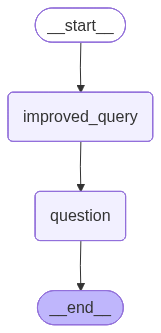

In [43]:
graph = StateGraph(UniInfosSTATE)
graph.add_node("improved_query",improved_query)
graph.add_node("question" , answerQuestion )
graph.add_edge(START , "improved_query")
graph.add_edge("improved_query" , "question")
graph.add_edge("question" , END)
app=graph.compile()
app


In [44]:
result=app.invoke({"user_query":"What is the capital of France?"})


KeyError: 'improved_query'